# Titanic - Machine Learning from Disaster
**Goal:** Predict survival on the Titanic using classification models.  
**Metric:** AUC-ROC  
**Structure:**
1. Imports & Config
2. Load Data
3. EDA
4. Preprocessing
5. Feature Selection
6. Modeling
7. Evaluation
8. Submission

## 1. Imports & Config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress optuna noise

import warnings
warnings.filterwarnings('ignore')

# reproducibility
SEED = 42
np.random.seed(SEED)

# plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# CV strategy — used consistently across all models
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

## 2. Load Data

In [2]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

# Save PassengerId before any transformation — needed for submission
passenger_ids = test_df['PassengerId'].copy()

# Lowercase column names for convenience
train_df.columns = train_df.columns.str.lower()
test_df.columns  = test_df.columns.str.lower()

# Drop columns that leak ID info or are too high-cardinality for baseline
drop_cols = ['passengerid', 'name', 'ticket', 'cabin']
train_df = train_df.drop(columns=drop_cols)
test_df  = test_df.drop(columns=drop_cols)

print('Train shape:', train_df.shape)
print('Test shape: ', test_df.shape)

Train shape: (891, 8)
Test shape:  (418, 7)


## 3. EDA

In [3]:
train_df.head().T

,0,1,2,3,4
survived,0,1,1,1,0
pclass,3,1,3,1,3
sex,male,female,female,female,male
age,22.0,38.0,26.0,35.0,35.0
sibsp,1,1,0,1,0
parch,0,0,0,0,0
fare,7.25,71.2833,7.925,53.1,8.05
embarked,S,C,S,S,S


In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


In [5]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [6]:
# Missing values — train and test side by side
missing = pd.DataFrame({
    'train_null':  train_df.isnull().sum(),
    'train_%':     (train_df.isnull().mean() * 100).round(1),
    'test_null':   test_df.isnull().sum(),
    'test_%':      (test_df.isnull().mean() * 100).round(1),
})
missing[missing.train_null > 0]

,train_null,train_%,test_null,test_%
age,177,19.9,86.0,20.6
embarked,2,0.2,0.0,0.0


In [7]:
# Target distribution
print(train_df.survived.value_counts())
print('Survival rate:', train_df.survived.mean().round(3))

survived
0    549
1    342
Name: count, dtype: int64
Survival rate: 0.384


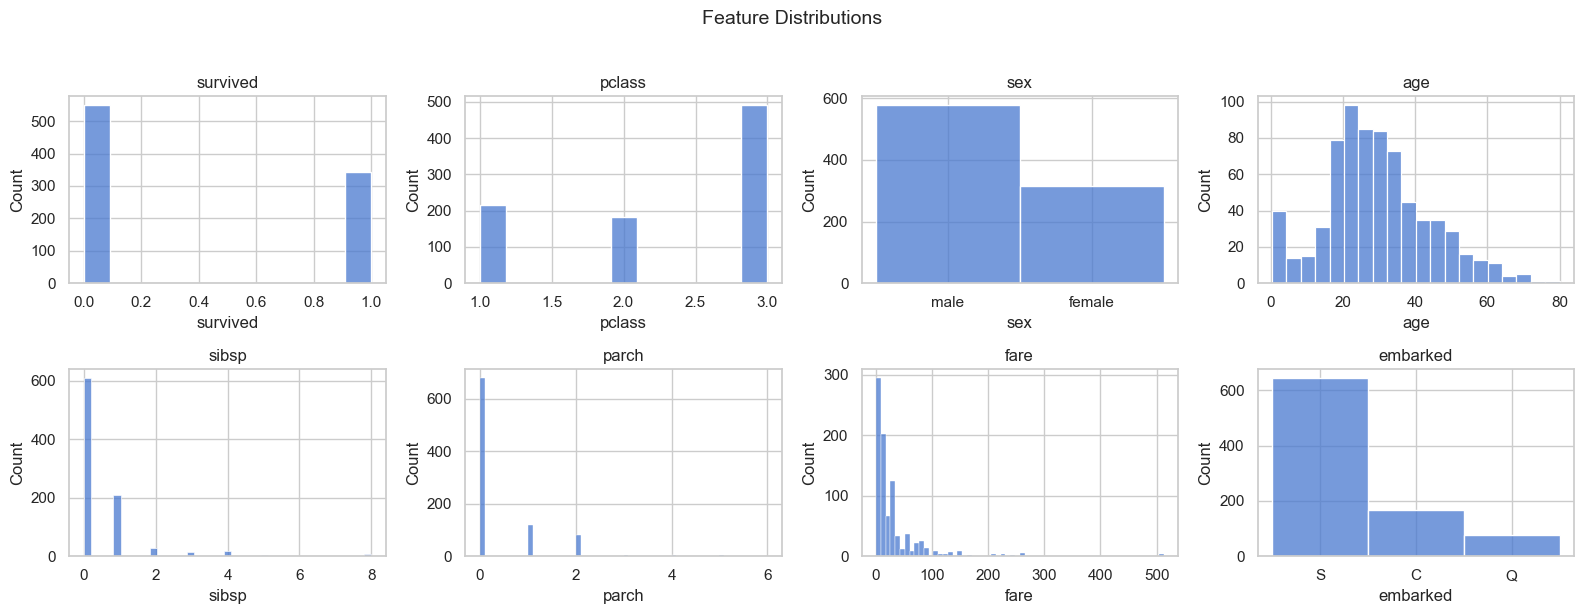

In [8]:
# Feature distributions — grid layout
cols = train_df.columns.tolist()
ncols = 4
nrows = -(-len(cols) // ncols)  # ceiling division

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(train_df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

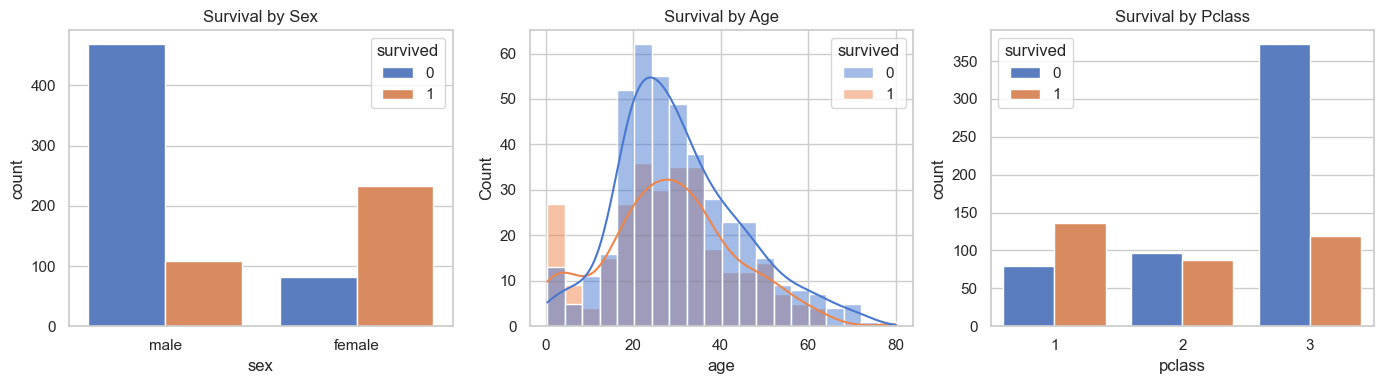

In [9]:
# Survived vs key features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.countplot(data=train_df, x='sex', hue='survived', ax=axes[0])
axes[0].set_title('Survival by Sex')

sns.histplot(data=train_df, x='age', hue='survived', kde=True, ax=axes[1])
axes[1].set_title('Survival by Age')

sns.countplot(data=train_df, x='pclass', hue='survived', ax=axes[2])
axes[2].set_title('Survival by Pclass')

plt.tight_layout()
plt.show()

## 4. Preprocessing

In [10]:
cat_columns = ['pclass', 'sex', 'embarked']
num_columns = ['age', 'sibsp', 'parch', 'fare']

# --- Imputation ---
# Categorical: mode
for col in cat_columns:
    mode = train_df[col].mode()[0]
    train_df[col] = train_df[col].fillna(mode)
    test_df[col]  = test_df[col].fillna(mode)  # use train mode for test too

# Numerical: median
for col in num_columns:
    median = train_df[col].median()
    train_df[col] = train_df[col].fillna(median)
    test_df[col]  = test_df[col].fillna(median)  # use train median for test

print('Train nulls after imputation:', train_df.isnull().sum().sum())
print('Test nulls after imputation: ', test_df.isnull().sum().sum())

Train nulls after imputation: 0
Test nulls after imputation:  0


In [11]:
# --- Encoding ---
train_df = pd.get_dummies(train_df, columns=cat_columns, drop_first=True, dtype=int)
test_df  = pd.get_dummies(test_df,  columns=cat_columns, drop_first=True, dtype=int)

# Align columns — test gets train's feature columns, missing filled with 0
feature_cols = [c for c in train_df.columns if c != 'survived']
test_df = test_df.reindex(columns=feature_cols, fill_value=0)

print('Train columns:', train_df.shape[1])
print('Test columns: ', test_df.shape[1])
train_df.head().T

Train columns: 10
Test columns:  9


,0,1,2,3,4
survived,0.00,1.0000,1.000,1.0,0.00
age,22.00,38.0000,26.000,35.0,35.00
sibsp,1.00,1.0000,0.000,1.0,0.00
parch,0.00,0.0000,0.000,0.0,0.00
fare,7.25,71.2833,7.925,53.1,8.05
pclass_2,0.00,0.0000,0.000,0.0,0.00
pclass_3,1.00,0.0000,1.000,0.0,1.00
sex_male,1.00,0.0000,0.000,0.0,1.00
embarked_Q,0.00,0.0000,0.000,0.0,0.00
embarked_S,1.00,0.0000,1.000,1.0,1.00


In [12]:
# --- Train/target split ---
X = train_df.drop('survived', axis=1)
y = train_df['survived']

print('X shape:', X.shape)
print('y distribution:\n', y.value_counts())

X shape: (891, 9)
y distribution:
 survived
0    549
1    342
Name: count, dtype: int64


## 5. Feature Selection

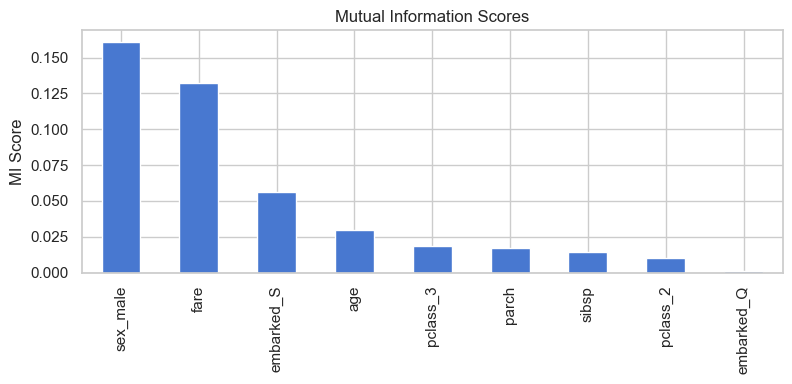

sex_male      0.160996
fare          0.132343
embarked_S    0.056038
age           0.030010
pclass_3      0.018236
parch         0.017246
sibsp         0.014494
pclass_2      0.009826
embarked_Q    0.001274
dtype: float64

In [13]:
# Mutual information for all features
mi_scores = mutual_info_classif(X, y, random_state=SEED)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
mi_series.plot(kind='bar', ax=ax)
ax.set_title('Mutual Information Scores')
ax.set_ylabel('MI Score')
plt.tight_layout()
plt.show()

mi_series

In [14]:
# Correlation with target
corr = X.corrwith(y).sort_values(ascending=False)
print('Correlation with survived:\n', corr.round(3))

Correlation with survived:
 fare          0.257
pclass_2      0.093
parch         0.082
embarked_Q    0.004
sibsp        -0.035
age          -0.065
embarked_S   -0.150
pclass_3     -0.322
sex_male     -0.543
dtype: float64


## 6. Modeling

Strategy: use full CV on all training data (no train_test_split).  
This is more reliable on small datasets like Titanic.

In [15]:
# Helper to evaluate any model with CV
def evaluate(name, model, X, y, cv):
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{name:30s} AUC: {scores.mean():.4f} ± {scores.std():.4f}')
    return scores.mean()

results = {}

In [16]:
# --- Baseline: Logistic Regression ---
# Needs scaling — use Pipeline to prevent data leakage across CV folds
logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=SEED))
])

results['LogisticRegression'] = evaluate('Logistic Regression', logreg_pipe, X, y, CV)

Logistic Regression            AUC: 0.8511 ± 0.0220


In [17]:
# --- Random Forest baseline ---
rf_base = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
results['RandomForest_base'] = evaluate('Random Forest (default)', rf_base, X, y, CV)

Random Forest (default)        AUC: 0.8704 ± 0.0269


In [18]:
# --- Random Forest + Optuna ---
def rf_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }
    model = RandomForestClassifier(**params, random_state=SEED, n_jobs=-1)
    return cross_val_score(model, X, y, cv=CV, scoring='roc_auc', n_jobs=-1).mean()

rf_study = optuna.create_study(direction='maximize')
rf_study.optimize(rf_objective, n_trials=100, show_progress_bar=True)

print('Best RF params:', rf_study.best_params, 4)
print('Best RF AUC:   ', round(rf_study.best_value, 4))

best_rf = RandomForestClassifier(**rf_study.best_params, random_state=SEED, n_jobs=-1)
results['RandomForest_tuned'] = evaluate('Random Forest (tuned)', best_rf, X, y, CV)

  0%|          | 0/100 [00:00<?, ?it/s]

Best RF params: {'n_estimators': 144, 'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'log2'} 4
Best RF AUC:    0.8841
Random Forest (tuned)          AUC: 0.8841 ± 0.0201


In [19]:
# --- XGBoost baseline ---
xgb_base = XGBClassifier(
    n_estimators=100, random_state=SEED,
    eval_metric='auc', verbosity=0, n_jobs=-1
)
results['XGBoost_base'] = evaluate('XGBoost (default)', xgb_base, X, y, CV)

XGBoost (default)              AUC: 0.8685 ± 0.0250


In [20]:
# --- XGBoost + Optuna ---
def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0, 1),
    }
    model = XGBClassifier(
        **params, random_state=SEED,
        eval_metric='auc', verbosity=0, n_jobs=-1
    )
    return cross_val_score(model, X, y, cv=CV, scoring='roc_auc', n_jobs=-1).mean()

xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=100, show_progress_bar=True)

print('Best XGB params:', xgb_study.best_params)
print('Best XGB AUC:   ', round(xgb_study.best_value, 4))

best_xgb = XGBClassifier(
    **xgb_study.best_params, random_state=SEED,
    eval_metric='auc', verbosity=0, n_jobs=-1
)
results['XGBoost_tuned'] = evaluate('XGBoost (tuned)', best_xgb, X, y, CV)

  0%|          | 0/100 [00:00<?, ?it/s]

Best XGB params: {'n_estimators': 413, 'max_depth': 8, 'learning_rate': 0.08143064885707992, 'subsample': 0.6090305677600085, 'colsample_bytree': 0.6968545234462618, 'min_child_weight': 1, 'gamma': 0.16848931681610596, 'reg_alpha': 0.9626101000494957, 'reg_lambda': 0.7156609755537414}
Best XGB AUC:    0.885
XGBoost (tuned)                AUC: 0.8850 ± 0.0230


## 7. Evaluation

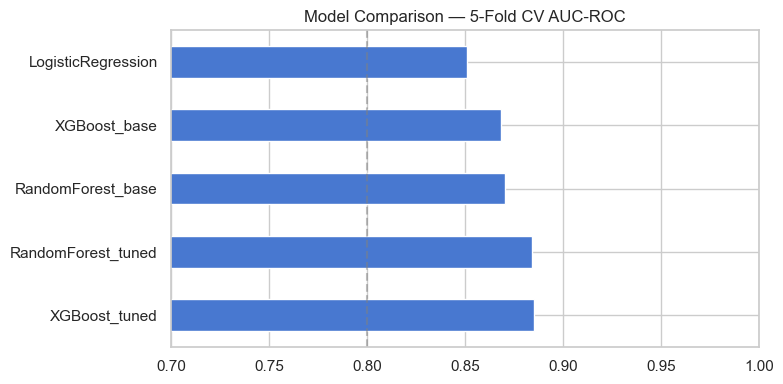

                    CV AUC-ROC
XGBoost_tuned           0.8850
RandomForest_tuned      0.8841
RandomForest_base       0.8704
XGBoost_base            0.8685
LogisticRegression      0.8511

Best model: XGBoost_tuned


In [21]:
# Compare all models
results_df = pd.Series(results).sort_values(ascending=False).to_frame('CV AUC-ROC')
results_df['CV AUC-ROC'] = results_df['CV AUC-ROC'].round(4)

fig, ax = plt.subplots(figsize=(8, 4))
results_df['CV AUC-ROC'].plot(kind='barh', ax=ax)
ax.set_xlim(0.7, 1.0)
ax.set_title('Model Comparison — 5-Fold CV AUC-ROC')
ax.axvline(0.8, linestyle='--', color='gray', alpha=0.5)
plt.tight_layout()
plt.show()

print(results_df)
best_model_name = results_df['CV AUC-ROC'].idxmax()
print(f'\nBest model: {best_model_name}')

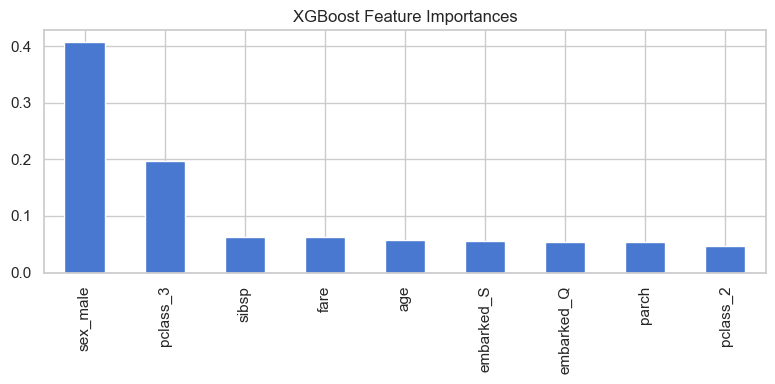

In [22]:
# Feature importance from best tree model
best_xgb.fit(X, y)
importances = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='bar', ax=ax)
ax.set_title('XGBoost Feature Importances')
plt.tight_layout()
plt.show()

## 8. Submission

In [23]:
# Fit best model on full training data and predict
best_xgb.fit(X, y)
predictions = best_xgb.predict(test_df)

submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived':    predictions
})

submission.to_csv('submission.csv', index=False)
print('Saved submission.csv')
submission.head(10)

Saved submission.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,0
7,899,0
8,900,1
9,901,0


In [24]:
# Sanity checks before submitting
assert submission['PassengerId'].nunique() == len(submission), 'Duplicate PassengerIds!'
assert submission['Survived'].isin([0, 1]).all(), 'Invalid prediction values!'
assert submission.isnull().sum().sum() == 0, 'Null values in submission!'

print('Shape:      ', submission.shape)
print('Predictions:', submission['Survived'].value_counts().to_dict())
print('All checks passed ✓')

Shape:       (418, 2)
Predictions: {0: 275, 1: 143}
All checks passed ✓
